In [2]:
#load the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
df = pd.read_csv('advertising.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nInfo:")
print(df.info())
print("\nNull values:")
print(df.isnull().sum())

Shape: (200, 4)

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']

First 5 rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Null values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


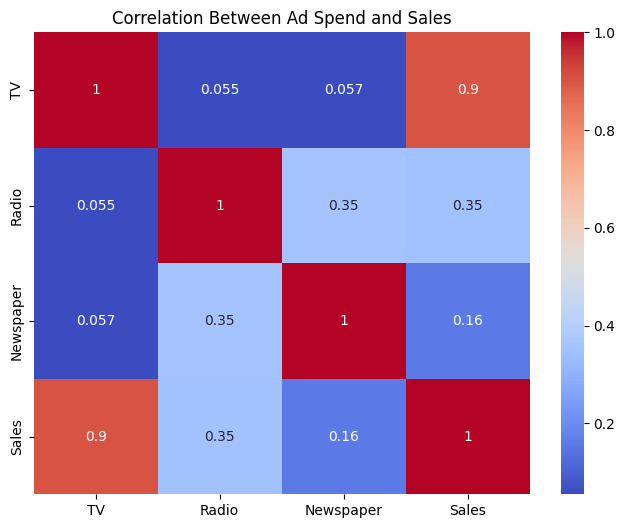

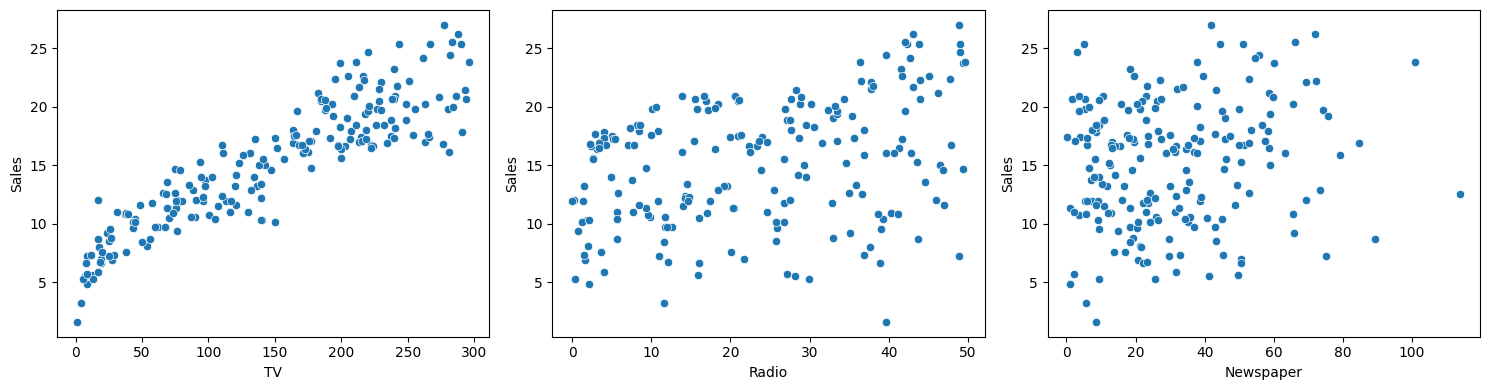

In [3]:
# EDA
df.describe()
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Ad Spend and Sales')
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(x='TV', y='Sales', data=df, ax=axes[0])
sns.scatterplot(x='Radio', y='Sales', data=df, ax=axes[1])
sns.scatterplot(x='Newspaper', y='Sales', data=df, ax=axes[2])
plt.tight_layout()
plt.show()

In [4]:
#Train model
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model trained
Coefficients: [0.05450927 0.10094536 0.00433665]
Intercept: 4.714126402214127


LINEAR REGRESSION RESULTS
R2 Score: 0.9059
RMSE: 1.7052
MAE: 1.2748


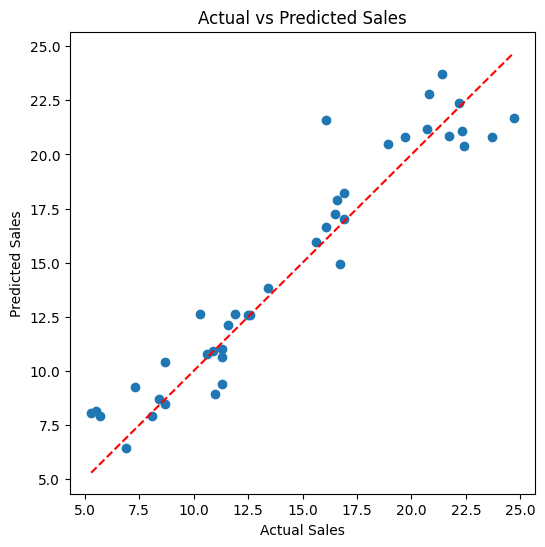

In [5]:
#Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print("="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)
print(f"R2 Score: {round(r2, 4)}")
print(f"RMSE: {round(rmse, 4)}")
print(f"MAE: {round(mae, 4)}")
print("="*50)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()